# 08. Structural mean shifts

Detect conservative piecewise-constant mean shifts separately inside the historical and the modern statistical regime, so the known 1995 splice is never a candidate economic break.

**Reads**

- `outputs/tables/structural_breaks.csv`
- `data/processed/fiscal_balances_1977_2025.csv`

**Writes**

- Nothing. The break table is persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 9

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. Why the model is deliberately modest

Fewer than fifty annual observations, split across two statistical regimes, do
not support a flexible change-point model. The specification is therefore:

- a piecewise-constant mean, with at most two breaks per regime;
- a minimum segment length of five years;
- exact dynamic-programming minimisation of within-segment squared error;
- BIC model selection, which may select zero breaks;
- separate estimation for 1977-1994 and 1995-2025.

In [2]:
breaks = pd.read_csv(TABLES / 'structural_breaks.csv')
display(breaks.round(3))

,regime,sector,n,n_breaks,break_years,segment_means_pct_gdp,bic
0,1977-1994_historical,general_government,18,1,1986,-8.0942;-4.7630,34.285
1,1977-1994_historical,central_government,18,1,1987,-8.1056;-4.7492,29.401
2,1977-1994_historical,regional_local_government,18,0,NaN,-0.2750,-33.052
3,1977-1994_historical,social_security_funds,18,0,NaN,0.4602,-24.847
4,1995-2025_modern,general_government,31,2,2009;2015,-4.3662;-7.9664;-1.4712,52.125
5,1995-2025_modern,central_government,31,2,2009;2016,-4.4779;-7.7736;-2.7526,40.276
6,1995-2025_modern,regional_local_government,31,2,2000;2011,-0.0006;-0.4598;0.1550,-72.763
7,1995-2025_modern,social_security_funds,31,2,2016;2021,0.3522;1.0925;1.8804,-50.954


## 2. Fitted segments

Each chart shows one balance series with the selected segment means drawn on top
and the break years marked. A flat line across the whole regime means BIC
selected no break at all.

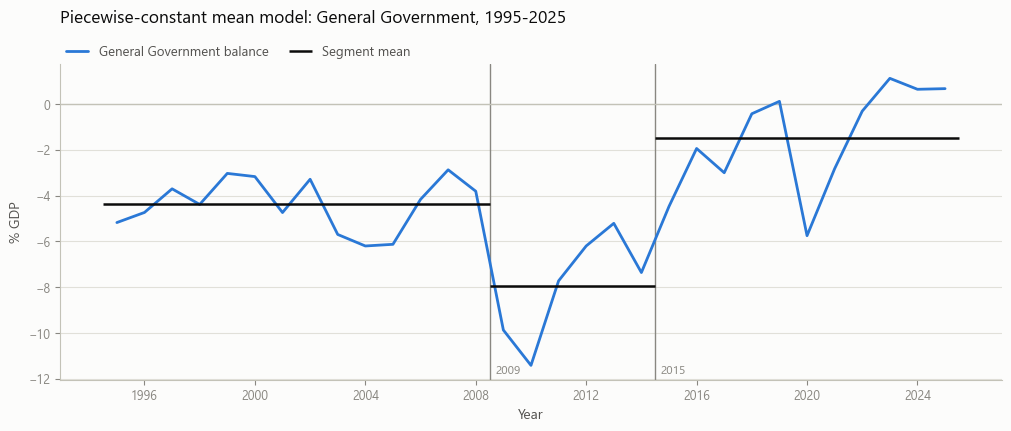

In [3]:
panel = pd.read_csv(PROCESSED / 'fiscal_balances_1977_2025.csv')
figure = figures.structural_break_segments(
    panel, breaks, sector='general_government', regime='1995-2025_modern'
)

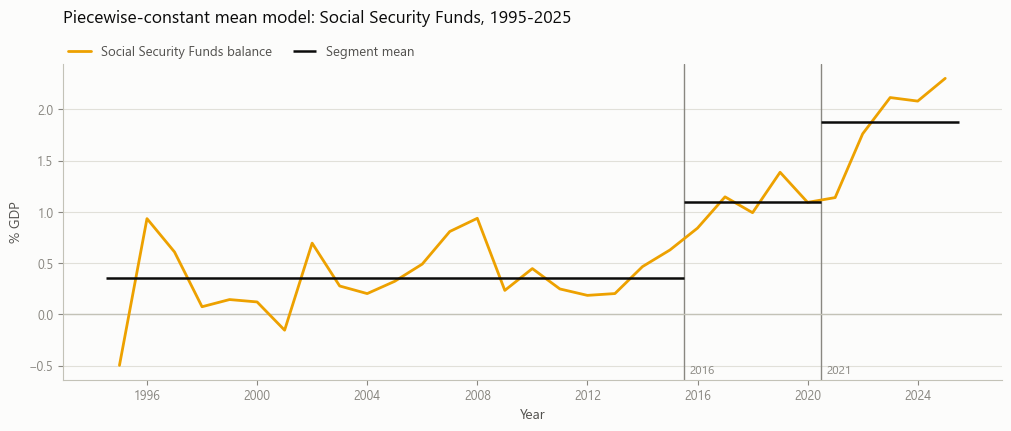

In [4]:
figure = figures.structural_break_segments(
    panel, breaks, sector='social_security_funds', regime='1995-2025_modern'
)

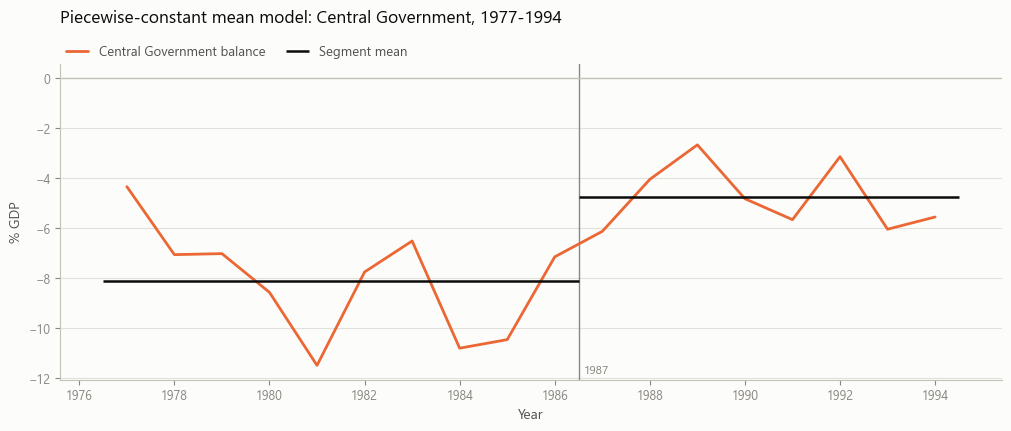

In [5]:
figure = figures.structural_break_segments(
    panel, breaks, sector='central_government', regime='1977-1994_historical'
)

## Interpretation limits

1. Break dates are **statistical summaries**. This notebook attaches no
   historical cause to any of them.
2. Detection is run **within** each regime. A shift at the 1995 boundary is
   unidentifiable here by construction, which is the intent.
3. A **five-year minimum segment** means shifts near the end of the sample cannot
   be detected yet.
4. Selecting a mean shift does **not** imply the underlying series is
   piecewise-constant; it is the best fit within a restricted model class.

---

[Previous: 07. Balance persistence and sign transitions](07_persistence.ipynb) | [Next: 09. Social Security Funds mechanisms](09_social_security_mechanisms.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```